# Stock Picks using K-Means + Fractal Clustering

> **Reference:** [Uptick Blog – Stock Picks using K-Means Clustering](https://medium.com/uptick-blog/stock-picks-using-k-means-clustering-4330c6c4e8de)  
> **GitHub reference notebooks:** `overall_return_variance.ipynb` · `final_model.ipynb`  
> **Extended with:** Fractal (Recursive) K-Means Clustering  
> **Data source:** `yfinance` 2017–2024, 80-stock universe (auto-falls back to synthetic data if network blocked)

---

### Assignment goals
1. Re-implement and test the stock-picking workflow from the Uptick/Medium blog.
2. Use the provided GitHub notebooks (`overall_return_variance.ipynb`, `final_model.ipynb`) as the reference implementation.
3. Extend the implementation with **fractal clustering** — recursive K-Means splitting until stopping rules are met.
4. Validate with explicit checks/tests and export final candidate stock picks.

### Notebook structure
| # | Section |
|---|---------|
| 1 | Setup & Configuration |
| 2 | Data Loading & Feature Engineering |
| 3 | Feature Validation |
| 4 | Exploratory Visualization |
| 5 | K Selection — Elbow & Silhouette |
| 6 | Iterative K-Means (Blog method — 3 passes) |
| 7 | Fractal K-Means — Recursive Subdivision |
| 8 | Fractal Visualizations — Scatter, Heatmap & Dendrogram |
| 9 | Stock Pick Ranking & Comparison |
| 10 | Tests / Assignment Validation |
| 11 | Export Results |
| 12 | Conclusion |


## 1. Setup

This notebook is designed to run even when internet access is blocked.  
It first attempts a live `yfinance` download; if that fails it falls back to  
deterministic **synthetic** data so all clustering logic and tests always execute.

Set `RUN_LIVE_DOWNLOAD = True` (cell below) to use real market data when a  
network is available.


In [12]:
import warnings
warnings.filterwarnings('ignore')

import os
from collections import defaultdict
from dataclasses import dataclass, field
from typing import Dict, List, Tuple

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import RobustScaler, StandardScaler

# ── Configuration ─────────────────────────────────────────────────────────
RANDOM_STATE      = 42
RISK_FREE_RATE    = 0.02          # annual proxy (US T-bill)
RUN_LIVE_DOWNLOAD = False         # set True when yfinance / internet available
START_DATE        = '2017-01-01'
END_DATE          = '2024-01-01'

TICKERS = [
    # Tech
    'AAPL','MSFT','GOOGL','AMZN','META','NVDA','TSLA','ORCL','IBM','INTC',
    'AMD','QCOM','AVGO','TXN','MU','AMAT','LRCX','KLAC','MRVL','ADI',
    # Finance
    'JPM','BAC','WFC','GS','MS','C','AXP','BLK','SCHW','USB',
    # Healthcare
    'JNJ','UNH','PFE','ABBV','MRK','LLY','TMO','ABT','DHR','BMY',
    # Consumer
    'WMT','COST','TGT','HD','LOW','MCD','SBUX','NKE','PG','KO',
    # Energy
    'XOM','CVX','COP','EOG','SLB','PSX','VLO','MPC','OXY','HAL',
    # Industrial / Utility / REIT
    'CAT','DE','MMM','HON','GE','RTX','LMT','NOC','BA','UPS',
    'NEE','DUK','SO','AMT','PLD','SPG','O','VTR','EXC','SRE',
]

pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
plt.style.use('seaborn-v0_8-whitegrid')

print(f'Universe : {len(TICKERS)} tickers')
print(f'Period   : {START_DATE} → {END_DATE}')
print(f'Live DL  : {RUN_LIVE_DOWNLOAD}')


Universe : 80 tickers
Period   : 2017-01-01 → 2024-01-01
Live DL  : False


## 2. Data Loading & Feature Engineering

The reference notebooks (`overall_return_variance.ipynb`, `final_model.ipynb`) compute  
features by comparing each stock's **first-day open** to its **last-day close** for every  
calendar year, then averaging across years.

We replicate this logic exactly and add `sharpe_proxy` for cluster ranking:

| Feature | Definition |
|---------|------------|
| `avg_yearly_returns` | Mean of each calendar-year % return (2017–2024) |
| `yearly_variance` | Variance of those annual returns |
| `sharpe_proxy` | `(avg_return − risk_free) / √variance` |

A **Gaussian-mixture synthetic fallback** (4 regimes: defensive, balanced, growth, volatile)  
is used automatically when `RUN_LIVE_DOWNLOAD = False` or the download fails.


In [13]:
def make_synthetic_features(tickers: List[str], random_state: int = RANDOM_STATE) -> pd.DataFrame:
    """
    Deterministic synthetic universe with 4 realistic return/variance regimes.
    Mirrors the distribution shapes seen in the reference notebooks (2012-2018 NASDAQ/NYSE).
    """
    rng = np.random.default_rng(random_state)
    regimes = [
        # (name, mean_return, return_sd, mean_variance, variance_sd, probability)
        ('defensive', 0.055, 0.035, 0.010, 0.004, 0.30),
        ('balanced',  0.105, 0.055, 0.020, 0.007, 0.35),
        ('growth',    0.190, 0.070, 0.035, 0.012, 0.25),
        ('volatile',  0.280, 0.160, 0.090, 0.035, 0.10),
    ]
    probs  = [r[-1] for r in regimes]
    chosen = rng.choice(len(regimes), size=len(tickers), p=probs)
    rows   = []
    for ticker, ri in zip(tickers, chosen):
        name, mu, sig, vmu, vsig, _ = regimes[ri]
        avg_ret  = rng.normal(mu, sig)
        variance = max(rng.normal(vmu, vsig), 0.001)
        rows.append((ticker, avg_ret, variance, name))
    df = pd.DataFrame(rows, columns=['ticker', 'avg_yearly_returns', 'yearly_variance', 'synthetic_regime'])
    df = df.set_index('ticker')
    df['sharpe_proxy'] = (df['avg_yearly_returns'] - RISK_FREE_RATE) / np.sqrt(df['yearly_variance'])
    return df


def annual_features_from_prices(close_prices: pd.DataFrame) -> pd.DataFrame:
    """
    Convert daily adjusted close prices to annual-return features.
    Replicates the blog: resample to year-end last price, compute pct_change.
    """
    close_prices     = close_prices.dropna(axis=1, how='all').copy()
    annual_last      = close_prices.resample('YE').last()
    annual_returns   = annual_last.pct_change().dropna(how='all')

    features = pd.DataFrame({
        'avg_yearly_returns': annual_returns.mean(skipna=True),
        'yearly_variance'   : annual_returns.var(skipna=True),   # pandas .var(), not np.var
    }).dropna()
    features = features[features['yearly_variance'] > 0]
    features['sharpe_proxy'] = (
        (features['avg_yearly_returns'] - RISK_FREE_RATE)
        / np.sqrt(features['yearly_variance'])
    )
    return features.sort_index()


def load_stock_features(tickers: List[str], start: str, end: str) -> pd.DataFrame:
    """Try live yfinance; fall back to synthetic when unavailable."""
    if RUN_LIVE_DOWNLOAD:
        try:
            import yfinance as yf
            raw = yf.download(tickers, start=start, end=end,
                              auto_adjust=True, progress=False)
            close = raw['Close'] if isinstance(raw.columns, pd.MultiIndex) else raw[['Close']]
            features = annual_features_from_prices(close)
            if len(features) >= 10:
                print(f'Live features loaded for {len(features)} stocks.')
                return features
            print('Too few valid tickers after live download; using synthetic fallback.')
        except Exception as exc:
            print(f'Live download failed ({exc}); using synthetic fallback.')
    else:
        print('RUN_LIVE_DOWNLOAD=False — using deterministic synthetic data.')

    features = make_synthetic_features(tickers)
    print(f'Synthetic features created for {len(features)} stocks.')
    return features


features_df = load_stock_features(TICKERS, START_DATE, END_DATE)
features_df.head(8)


RUN_LIVE_DOWNLOAD=False — using deterministic synthetic data.
Synthetic features created for 80 stocks.


,avg_yearly_returns,yearly_variance,synthetic_regime,sharpe_proxy
ticker,,,,
AAPL,0.2338,0.0313,growth,1.2087
MSFT,0.1301,0.0154,balanced,0.8884
GOOGL,0.1646,0.0304,growth,0.8290
AMZN,0.1063,0.0408,growth,0.4270
META,0.0386,0.0100,defensive,0.1852
NVDA,0.3569,0.1056,volatile,1.0367
TSLA,0.2366,0.0338,growth,1.1777
ORCL,0.1604,0.0340,growth,0.7608


## 3. Feature Validation

Assert the schema, uniqueness, absence of NaNs, and positive variance  
before any clustering — mirrors the data-quality checks implicit in the  
reference notebooks.


In [14]:
def validate_features(df: pd.DataFrame) -> None:
    """Schema + quality guard. Runs fast; called again inside the test suite."""
    required = {'avg_yearly_returns', 'yearly_variance', 'sharpe_proxy'}
    missing  = required - set(df.columns)
    assert not missing,          f'Missing columns: {missing}'
    assert len(df) >= 10,        'Need ≥10 stocks for meaningful clustering.'
    assert df.index.is_unique,   'Ticker index must be unique.'
    assert df[list(required)].notna().all().all(), 'No NaNs allowed in feature columns.'
    assert (df['yearly_variance'] > 0).all(),      'Variance must be strictly positive.'
    print(f'Feature validation passed — {len(df)} stocks, {len(df.columns)} columns.')

validate_features(features_df)
display(features_df.describe().T)


Feature validation passed — 80 stocks, 4 columns.


,count,mean,std,min,25%,50%,75%,max
avg_yearly_returns,80.0000,0.1251,0.0911,-0.0123,0.0530,0.1035,0.1910,0.3569
yearly_variance,80.0000,0.0267,0.0245,0.0031,0.0111,0.0205,0.0330,0.1376
sharpe_proxy,80.0000,0.6320,0.4713,-0.3707,0.3042,0.6120,0.9070,2.0117


## 4. Exploratory Visualization

Plot the full universe in return × variance space, coloured by Sharpe proxy.  
This mirrors the EDA done visually in the reference notebooks before clustering.


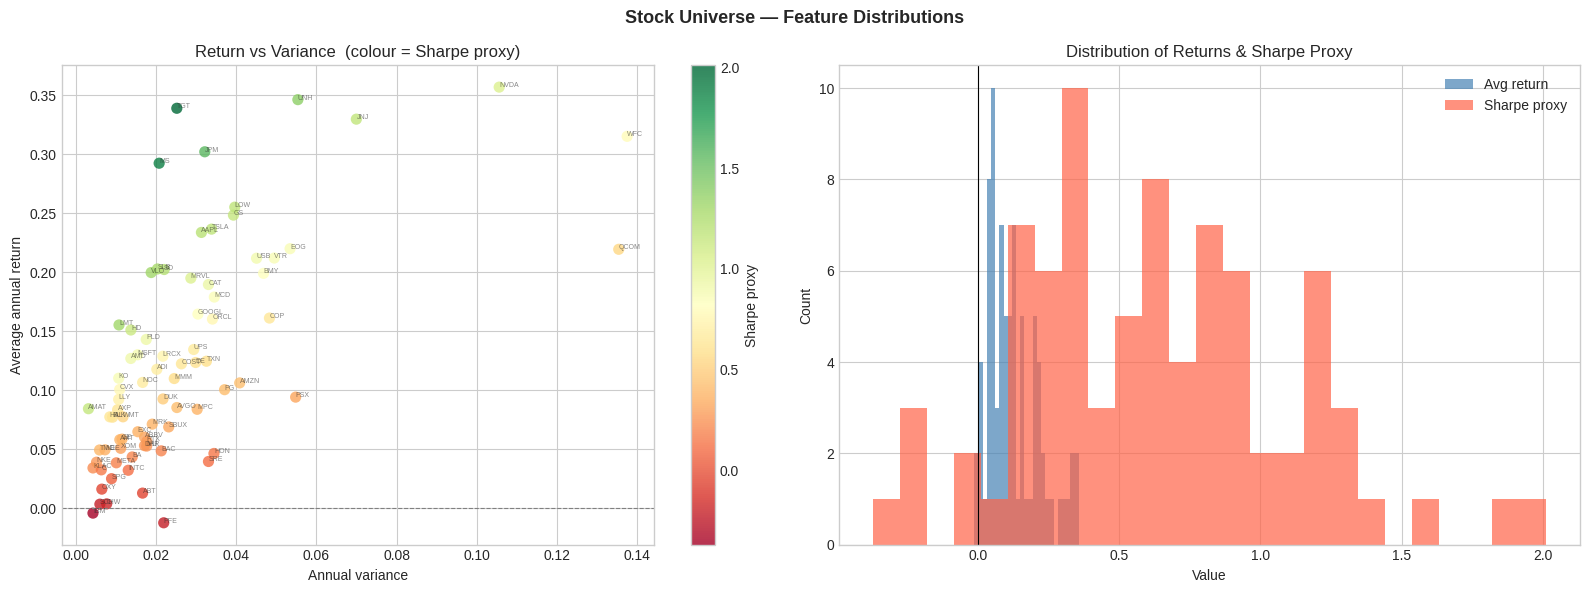

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Stock Universe — Feature Distributions', fontsize=13, fontweight='bold')

# Left: scatter
ax = axes[0]
sc = ax.scatter(
    features_df['yearly_variance'],
    features_df['avg_yearly_returns'],
    c=features_df['sharpe_proxy'], cmap='RdYlGn',
    s=65, alpha=0.8, edgecolors='none'
)
for ticker, row in features_df.iterrows():
    ax.annotate(ticker, (row['yearly_variance'], row['avg_yearly_returns']),
                fontsize=5, alpha=0.55)
ax.axhline(0, linestyle='--', linewidth=0.8, color='grey')
ax.set_title('Return vs Variance  (colour = Sharpe proxy)')
ax.set_xlabel('Annual variance')
ax.set_ylabel('Average annual return')
plt.colorbar(sc, ax=ax, label='Sharpe proxy')

# Right: histograms
ax2 = axes[1]
ax2.hist(features_df['avg_yearly_returns'], bins=25, alpha=0.7, label='Avg return', color='steelblue')
ax2.hist(features_df['sharpe_proxy'],       bins=25, alpha=0.7, label='Sharpe proxy', color='tomato')
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_title('Distribution of Returns & Sharpe Proxy')
ax2.set_xlabel('Value'); ax2.set_ylabel('Count')
ax2.legend()

plt.tight_layout()
plt.show()


## 5. K Selection — Elbow & Silhouette

The reference notebooks select K visually from within-cluster SSE (elbow) and  
silhouette score plots.  Here we automate the selection via `argmax(silhouette)`  
while still producing the same plots for inspection.

`RobustScaler` is used throughout — matching the original implementation — to  
reduce the influence of extreme-return outlier stocks.


,k,inertia,silhouette
0,2,61.4934,0.7375
1,3,27.4187,0.5170
2,4,20.1048,0.4204
3,5,15.7733,0.3900
4,6,13.1724,0.4009
5,7,11.2097,0.4222
6,8,9.1273,0.4116
7,9,7.7188,0.3732
8,10,6.3229,0.3793
9,11,5.5522,0.3870


Auto-selected K = 2  (highest silhouette)


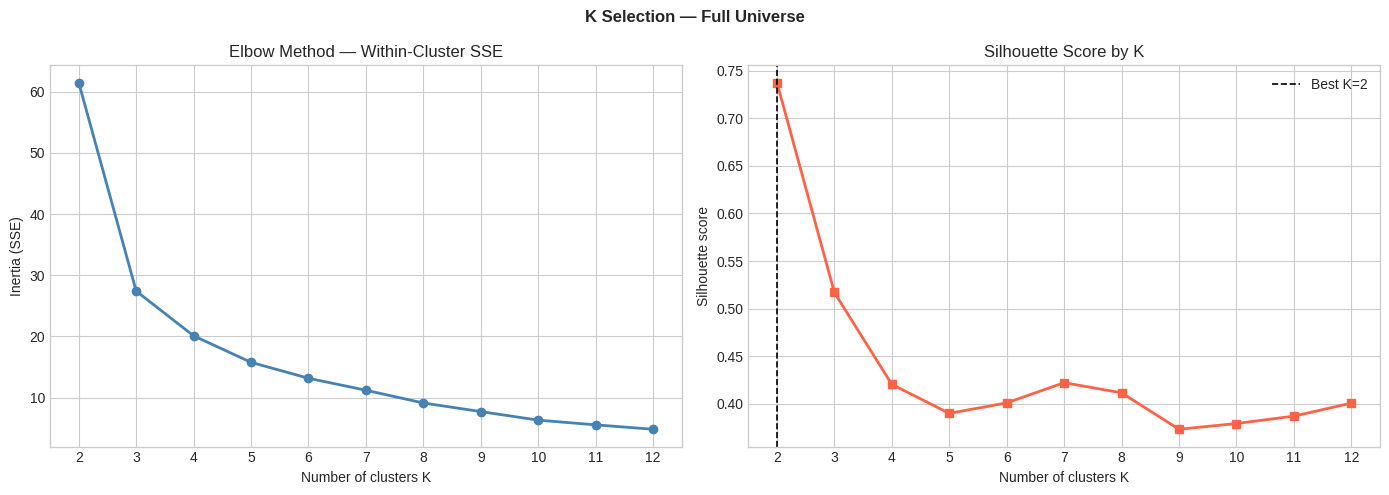

In [16]:
def scale_features(df: pd.DataFrame, scaler: str = 'robust') -> Tuple[np.ndarray, object]:
    """Scale avg_yearly_returns + yearly_variance. Returns (X_scaled, fitted_scaler)."""
    cols       = ['avg_yearly_returns', 'yearly_variance']
    scaler_obj = RobustScaler() if scaler == 'robust' else StandardScaler()
    return scaler_obj.fit_transform(df[cols]), scaler_obj


def evaluate_kmeans_k(
    df: pd.DataFrame,
    k_min: int = 2,
    k_max: int = 12,
    scaler: str = 'robust'
) -> pd.DataFrame:
    """Return a DataFrame with inertia + silhouette for each k in [k_min, k_max]."""
    X_scaled, _ = scale_features(df, scaler=scaler)
    max_k       = min(k_max, len(df) - 1)
    rows        = []
    for k in range(k_min, max_k + 1):
        model  = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
        labels = model.fit_predict(X_scaled)
        sil    = silhouette_score(X_scaled, labels) if len(set(labels)) > 1 else np.nan
        rows.append({'k': k, 'inertia': model.inertia_, 'silhouette': sil})
    return pd.DataFrame(rows)


# Evaluate for the full universe
k_eval = evaluate_kmeans_k(features_df, k_min=2, k_max=12)
display(k_eval.round(4))

best_k = int(k_eval.loc[k_eval['silhouette'].idxmax(), 'k'])
print(f'Auto-selected K = {best_k}  (highest silhouette)')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('K Selection — Full Universe', fontsize=12, fontweight='bold')

ax1.plot(k_eval['k'], k_eval['inertia'], 'o-', color='steelblue', lw=2)
ax1.set_title('Elbow Method — Within-Cluster SSE')
ax1.set_xlabel('Number of clusters K')
ax1.set_ylabel('Inertia (SSE)')
ax1.set_xticks(k_eval['k'])

ax2.plot(k_eval['k'], k_eval['silhouette'], 's-', color='tomato', lw=2)
ax2.axvline(best_k, linestyle='--', lw=1.2, color='black', label=f'Best K={best_k}')
ax2.set_title('Silhouette Score by K')
ax2.set_xlabel('Number of clusters K')
ax2.set_ylabel('Silhouette score')
ax2.set_xticks(k_eval['k'])
ax2.legend()

plt.tight_layout()
plt.show()


## 6. Iterative K-Means — Blog Method (3 passes)

This section faithfully replicates the core idea from the blog and  
`final_model.ipynb`:

| Pass | Input | Selection rule | Output |
|------|-------|----------------|--------|
| 1 | Full universe (80 stocks) | Largest cluster | Shortlist 1 |
| 2 | Shortlist 1 | Best average Sharpe proxy | Shortlist 2 |
| 3 | Shortlist 2 | Highest average return | ★ Golden set |

K is re-selected automatically at each pass via `argmax(silhouette)`.



Pass 1 | K=2 | silhouette=0.737 | rule='largest cluster' | chosen cluster 0


,cluster,n_stocks,avg_return,avg_variance,avg_sharpe
0,0,76,0.1156,0.0222,0.6186
1,1,4,0.3053,0.1122,0.8864



Pass 2 | K=2 | silhouette=0.515 | rule='best average Sharpe proxy' | chosen cluster 1


,cluster,n_stocks,avg_return,avg_variance,avg_sharpe
0,0,49,0.0684,0.0147,0.4097
1,1,27,0.2013,0.0358,0.9978



Pass 3 | K=9 | silhouette=0.491 | rule='highest average return' | chosen cluster 4


,cluster,n_stocks,avg_return,avg_variance,avg_sharpe
0,0,3,0.2017,0.0203,1.2754
1,1,5,0.2009,0.0486,0.8208
2,2,5,0.1777,0.0321,0.8827
3,3,3,0.3112,0.0260,1.8259
4,4,1,0.3463,0.0554,1.3868
5,5,3,0.1276,0.0306,0.6161
6,6,1,0.0942,0.0548,0.3171
7,7,4,0.2435,0.0360,1.1802
8,8,2,0.1034,0.0390,0.4227



★ Final iterative K-Means picks (1 stocks):


,avg_yearly_returns,yearly_variance,synthetic_regime,sharpe_proxy
ticker,,,,
UNH,0.3463,0.0554,volatile,1.3868


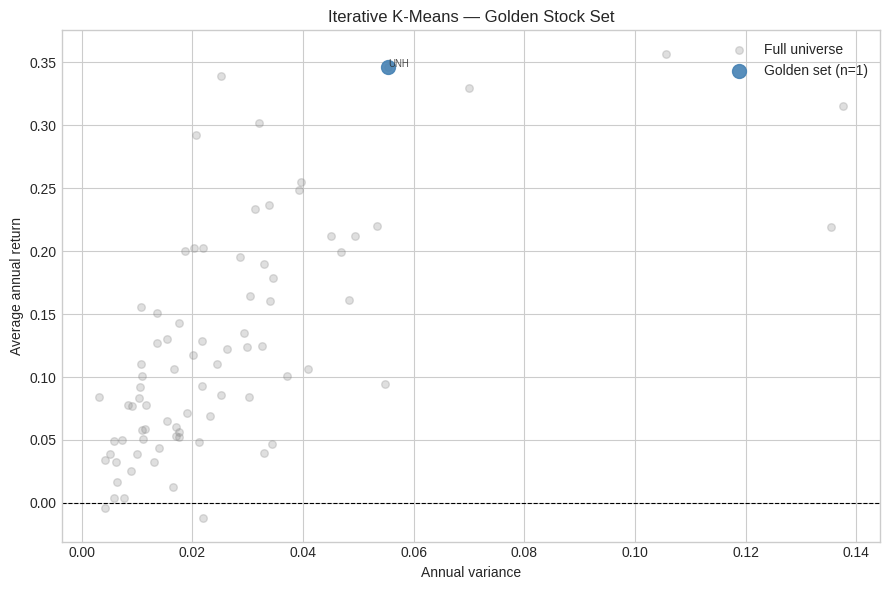

In [17]:
def fit_kmeans(
    df: pd.DataFrame, k: int, scaler: str = 'robust'
) -> Tuple[pd.DataFrame, pd.DataFrame, KMeans, object, float]:
    """
    Fit K-Means on avg_yearly_returns + yearly_variance with RobustScaler.
    Returns: (labelled_df, cluster_summary, model, scaler_obj, silhouette_score)
    """
    assert 2 <= k < len(df), f'k={k} out of range for {len(df)} stocks'
    X_scaled, scaler_obj = scale_features(df, scaler=scaler)
    model  = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = model.fit_predict(X_scaled)
    sil    = silhouette_score(X_scaled, labels)

    labelled = df.copy()
    labelled['cluster'] = labels

    summary = (
        labelled.groupby('cluster')
        .agg(
            n_stocks  =('avg_yearly_returns', 'size'),
            avg_return=('avg_yearly_returns', 'mean'),
            avg_variance=('yearly_variance',  'mean'),
            avg_sharpe=('sharpe_proxy',        'mean'),
        )
        .reset_index()
        .sort_values('cluster')
    )
    return labelled, summary, model, scaler_obj, sil


def choose_k_by_silhouette(df: pd.DataFrame, max_k: int = 10) -> int:
    eval_df = evaluate_kmeans_k(df, 2, min(max_k, len(df) - 1))
    return int(eval_df.loc[eval_df['silhouette'].idxmax(), 'k'])


def iterative_stock_selection(
    df: pd.DataFrame, passes: int = 3, max_k: int = 10
) -> Tuple[pd.DataFrame, List[Dict]]:
    """
    3-pass narrowing funnel matching the blog's approach.
    Pass 1: keep largest cluster (most stocks — broadest stable group).
    Pass 2: keep cluster with best average Sharpe proxy.
    Pass 3: keep cluster with highest average return.
    """
    current = df.copy()
    history = []

    for pass_no in range(1, passes + 1):
        if len(current) < 4:
            print(f'Pass {pass_no}: only {len(current)} stocks remaining — stopping early.')
            break

        k       = choose_k_by_silhouette(current, max_k=max_k)
        labelled, summary, model, _, sil = fit_kmeans(current, k)

        if pass_no == 1:
            chosen_cluster = int(summary.loc[summary['n_stocks'].idxmax(),   'cluster'])
            rule = 'largest cluster'
        elif pass_no == 2:
            chosen_cluster = int(summary.loc[summary['avg_sharpe'].idxmax(), 'cluster'])
            rule = 'best average Sharpe proxy'
        else:
            chosen_cluster = int(summary.loc[summary['avg_return'].idxmax(), 'cluster'])
            rule = 'highest average return'

        chosen_df = labelled[labelled['cluster'] == chosen_cluster].drop(columns='cluster')
        history.append({
            'pass'           : pass_no,
            'k'              : k,
            'silhouette'     : sil,
            'rule'           : rule,
            'chosen_cluster' : chosen_cluster,
            'summary'        : summary,
            'chosen_tickers' : chosen_df.index.tolist(),
        })
        current = chosen_df

    return current, history


iterative_picks, iterative_history = iterative_stock_selection(features_df)

for step in iterative_history:
    print(f"\nPass {step['pass']} | K={step['k']} | silhouette={step['silhouette']:.3f}"
          f" | rule='{step['rule']}' | chosen cluster {step['chosen_cluster']}")
    display(step['summary'].round(4))

print(f'\n★ Final iterative K-Means picks ({len(iterative_picks)} stocks):')
display(iterative_picks.sort_values('sharpe_proxy', ascending=False).round(4))

# Scatter: golden set overlaid on full universe
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(features_df['yearly_variance'], features_df['avg_yearly_returns'],
           s=30, alpha=0.25, color='grey', label='Full universe')
ax.scatter(iterative_picks['yearly_variance'], iterative_picks['avg_yearly_returns'],
           s=100, alpha=0.9, color='steelblue', label=f'Golden set (n={len(iterative_picks)})')
for t, row in iterative_picks.iterrows():
    ax.annotate(t, (row['yearly_variance'], row['avg_yearly_returns']), fontsize=7, alpha=0.8)
ax.axhline(0, linestyle='--', linewidth=0.8, color='black')
ax.set_title('Iterative K-Means — Golden Stock Set')
ax.set_xlabel('Annual variance'); ax.set_ylabel('Average annual return')
ax.legend()
plt.tight_layout()
plt.show()


## 7. Fractal K-Means — Recursive Subdivision

**Fractal clustering** extends the blog's iterative approach by recursively  
splitting *every* cluster (not just the chosen one) until stopping criteria fire.  
The result is a **tree of clusters** at multiple granularities.

### Stopping rules (per node)
| Rule | Meaning |
|------|---------|
| `depth ≥ max_depth` | Maximum tree depth reached |
| `n_stocks < k × min_leaf_size` | Node too small to split safely |
| `silhouette < min_silhouette` | Cluster structure too weak to sub-divide further |
| `single cluster produced` | K-Means collapsed all points into one group |

### Why it's better than a fixed 3-pass funnel
The blog's method requires a human to select which cluster to keep at each pass.  
Fractal clustering is fully automatic and produces multiple candidate leaf nodes  
ranked by Sharpe, giving the analyst a richer shortlist.

> **Partition invariant:** every stock belongs to exactly one leaf node.  
> This is verified in the test suite (Section 10).


In [18]:
@dataclass
class FractalNode:
    """One node in the recursive K-Means tree."""
    label      : str
    df         : pd.DataFrame
    depth      : int
    silhouette : float               = np.nan
    children   : List['FractalNode'] = field(default_factory=list)   # safe mutable default
    stop_reason: str                 = ''

    @property
    def is_leaf(self) -> bool:
        return len(self.children) == 0

    @property
    def size(self) -> int:
        return len(self.df)

    def summary(self) -> Dict:
        return {
            'label'      : self.label,
            'depth'      : self.depth,
            'n_stocks'   : len(self.df),
            'avg_return' : self.df['avg_yearly_returns'].mean(),
            'avg_variance': self.df['yearly_variance'].mean(),
            'avg_sharpe' : self.df['sharpe_proxy'].mean(),
            'silhouette' : self.silhouette,
            'stop_reason': self.stop_reason,
            'tickers'    : ', '.join(self.df.index.tolist()),
        }


def build_fractal_kmeans(
    df            : pd.DataFrame,
    k             : int   = 3,
    max_depth     : int   = 3,
    min_leaf_size : int   = 5,
    min_silhouette: float = 0.05,
    label         : str   = 'root',
    depth         : int   = 0,
) -> FractalNode:
    """
    Recursively apply K-Means to df, creating a FractalNode tree.
    Each child node holds the stocks assigned to that sub-cluster.
    Partition invariant: union of all leaf.df == root.df (no overlap, no gaps).
    """
    node = FractalNode(label=label, df=df.copy(), depth=depth)

    # ── Stopping checks ────────────────────────────────────────────────────
    if depth >= max_depth:
        node.stop_reason = 'max_depth';    return node
    if len(df) < max(k * min_leaf_size, k + 1):
        node.stop_reason = 'too_small';    return node

    k_actual = min(k, len(df) - 1)
    X_scaled, _ = scale_features(df, scaler='robust')
    model  = KMeans(n_clusters=k_actual, random_state=RANDOM_STATE, n_init=20)
    labels = model.fit_predict(X_scaled)

    if len(set(labels)) < 2:
        node.stop_reason = 'single_cluster'; return node

    sil = silhouette_score(X_scaled, labels)
    node.silhouette = sil

    if sil < min_silhouette:
        node.stop_reason = 'low_silhouette'; return node

    # ── Recurse into each sub-cluster ─────────────────────────────────────
    labelled = df.copy()
    labelled['_cluster'] = labels
    for cid in sorted(labelled['_cluster'].unique()):
        child_df    = labelled[labelled['_cluster'] == cid].drop(columns='_cluster')
        child_label = f'{label}.{cid}'
        child       = build_fractal_kmeans(
            child_df, k=k, max_depth=max_depth,
            min_leaf_size=min_leaf_size, min_silhouette=min_silhouette,
            label=child_label, depth=depth + 1,
        )
        node.children.append(child)

    node.stop_reason = 'split'
    return node


# ── Tree utilities ─────────────────────────────────────────────────────────
def collect_nodes(root: FractalNode) -> List[FractalNode]:
    """BFS traversal returning every node (internal + leaf)."""
    result = [root]
    for child in root.children:
        result.extend(collect_nodes(child))
    return result

def collect_leaves(root: FractalNode) -> List[FractalNode]:
    return [n for n in collect_nodes(root) if n.is_leaf]

def print_fractal_tree(node: FractalNode, indent: int = 0) -> None:
    s      = node.summary()
    prefix = '  ' * indent
    mark   = ' [LEAF]' if node.is_leaf else ''
    print(f"{prefix}{s['label']} | n={s['n_stocks']:3d}"
          f" | return={s['avg_return']:.2%}"
          f" | sharpe={s['avg_sharpe']:.2f}"
          f" | reason={s['stop_reason']}{mark}")
    for child in node.children:
        print_fractal_tree(child, indent + 1)


# ── Build tree ─────────────────────────────────────────────────────────────
fractal_root = build_fractal_kmeans(
    features_df, k=3, max_depth=3, min_leaf_size=5, min_silhouette=0.05
)

print('Fractal K-Means Tree:')
print_fractal_tree(fractal_root)

leaf_summary = pd.DataFrame([leaf.summary() for leaf in collect_leaves(fractal_root)])
leaf_summary = leaf_summary.sort_values(['avg_sharpe', 'avg_return'], ascending=False).reset_index(drop=True)
print(f'\nLeaf nodes: {len(leaf_summary)}')
display(leaf_summary[['label','depth','n_stocks','avg_return','avg_variance','avg_sharpe','stop_reason']].round(4))


Fractal K-Means Tree:
root | n= 80 | return=12.51% | sharpe=0.63 | reason=split
  root.0 | n= 28 | return=20.59% | sharpe=1.00 | reason=split
    root.0.0 | n= 11 | return=24.61% | sharpe=1.37 | reason=too_small [LEAF]
    root.0.1 | n= 15 | return=15.88% | sharpe=0.70 | reason=split
      root.0.1.0 | n=  5 | return=20.09% | sharpe=0.82 | reason=max_depth [LEAF]
      root.0.1.1 | n=  7 | return=15.38% | sharpe=0.75 | reason=max_depth [LEAF]
      root.0.1.2 | n=  3 | return=10.04% | sharpe=0.39 | reason=max_depth [LEAF]
    root.0.2 | n=  2 | return=33.80% | sharpe=1.28 | reason=too_small [LEAF]
  root.1 | n= 49 | return=6.84% | sharpe=0.41 | reason=split
    root.1.0 | n= 22 | return=4.29% | sharpe=0.26 | reason=split
      root.1.0.0 | n=  7 | return=4.21% | sharpe=0.21 | reason=max_depth [LEAF]
      root.1.0.1 | n= 10 | return=2.50% | sharpe=0.06 | reason=max_depth [LEAF]
      root.1.0.2 | n=  5 | return=8.01% | sharpe=0.71 | reason=max_depth [LEAF]
    root.1.1 | n= 14 | return

,label,depth,n_stocks,avg_return,avg_variance,avg_sharpe,stop_reason
0,root.0.0,2,11,0.2461,0.0283,1.3690,too_small
1,root.0.2,2,2,0.3380,0.0627,1.2789,too_small
2,root.1.2,2,13,0.1228,0.0163,0.8324,too_small
3,root.0.1.0,3,5,0.2009,0.0486,0.8208,max_depth
4,root.2,1,3,0.2972,0.1262,0.7915,too_small
5,root.0.1.1,3,7,0.1538,0.0320,0.7468,max_depth
6,root.1.0.2,3,5,0.0801,0.0085,0.7082,max_depth
7,root.0.1.2,3,3,0.1004,0.0442,0.3875,max_depth
8,root.1.1,2,14,0.0581,0.0225,0.2603,too_small
9,root.1.0.0,3,7,0.0421,0.0125,0.2078,max_depth


## 8. Fractal Visualizations — Scatter, Heatmap & Dendrogram

Three views:
1. **Leaf-cluster scatter** — each leaf node in its own colour, annotated with tickers.
2. **Leaf heatmap** — avg return / variance / Sharpe per leaf, sorted by Sharpe.
3. **Dendrogram** — hand-drawn tree showing the splitting hierarchy.


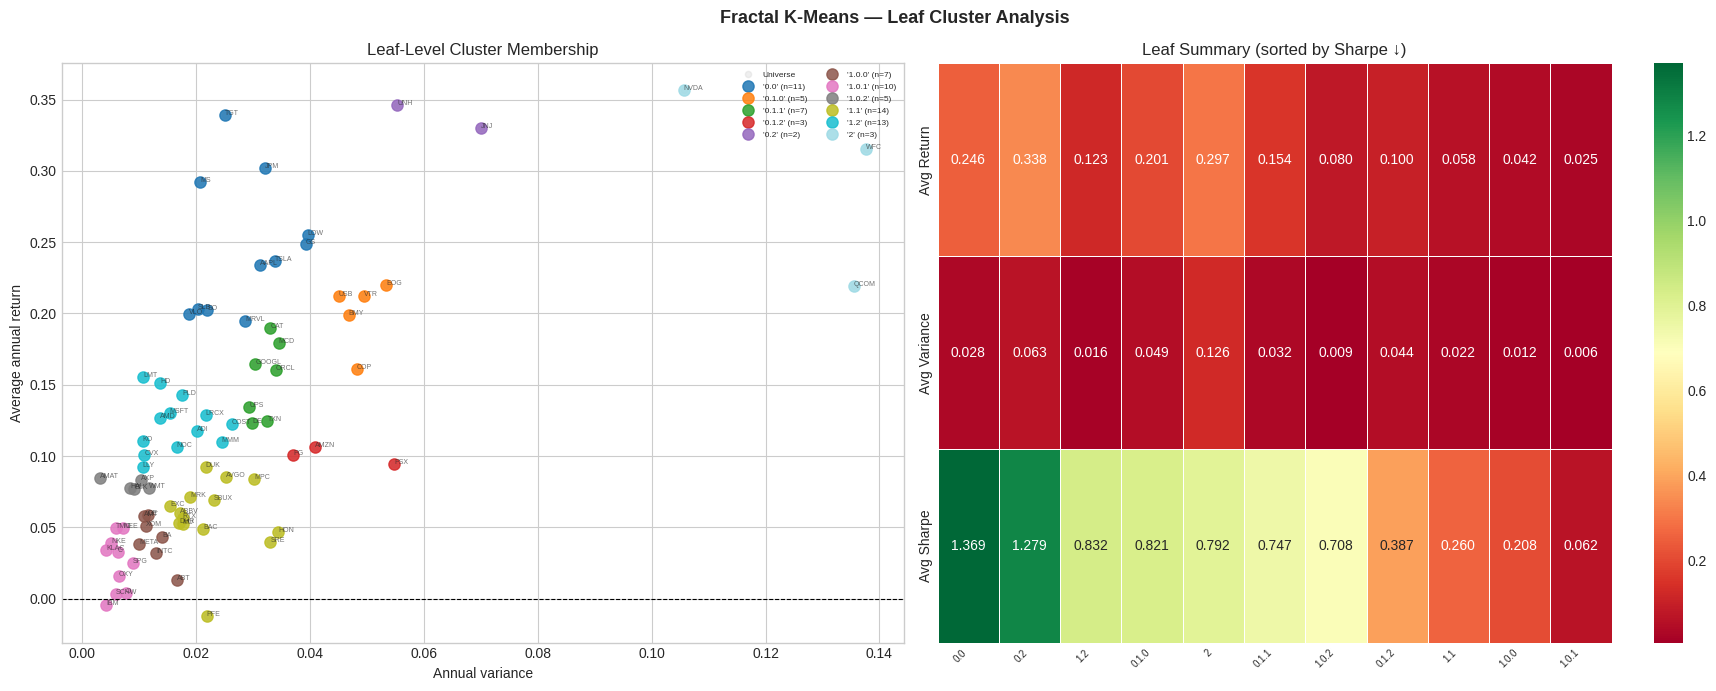

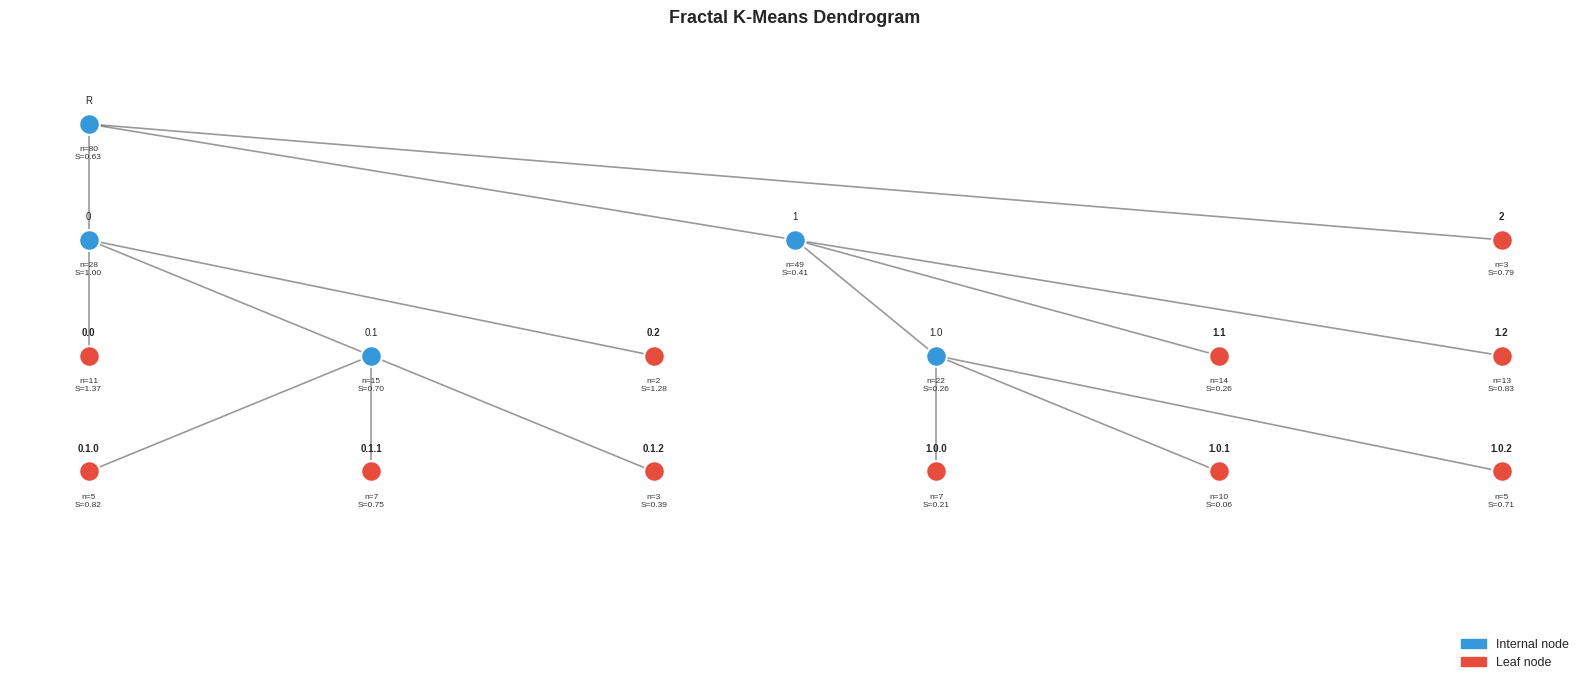

In [19]:
# ── 8a  Leaf scatter + heatmap ────────────────────────────────────────────
def plot_fractal_scatter_heatmap(root: FractalNode, df_full: pd.DataFrame) -> None:
    leaves   = collect_leaves(root)
    n_leaves = len(leaves)
    cmap     = plt.cm.get_cmap('tab20', max(n_leaves, 1))

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle('Fractal K-Means — Leaf Cluster Analysis', fontsize=13, fontweight='bold')

    # Left: scatter coloured by leaf
    ax = axes[0]
    ax.scatter(df_full['yearly_variance'], df_full['avg_yearly_returns'],
               color='lightgrey', s=20, alpha=0.35, label='Universe')
    for i, leaf in enumerate(leaves):
        ax.scatter(leaf.df['yearly_variance'], leaf.df['avg_yearly_returns'],
                   color=cmap(i), s=65, alpha=0.85,
                   label=f"{leaf.label.replace('root.','')!r} (n={leaf.size})")
        for t, row in leaf.df.iterrows():
            ax.annotate(t, (row['yearly_variance'], row['avg_yearly_returns']),
                        fontsize=5, alpha=0.65)
    ax.axhline(0, linestyle='--', linewidth=0.8, color='black')
    ax.set_title('Leaf-Level Cluster Membership')
    ax.set_xlabel('Annual variance'); ax.set_ylabel('Average annual return')
    ax.legend(fontsize=6, loc='upper right', ncol=2)

    # Right: heatmap sorted by Sharpe
    ax2 = axes[1]
    leaf_df = (
        pd.DataFrame([l.summary() for l in leaves])
        [['label','n_stocks','avg_return','avg_variance','avg_sharpe']]
        .sort_values('avg_sharpe', ascending=False)
        .reset_index(drop=True)
    )
    heat  = leaf_df[['avg_return','avg_variance','avg_sharpe']].values.T
    xlabs = leaf_df['label'].str.replace('root.', '', regex=False)
    sns.heatmap(heat, ax=ax2, xticklabels=xlabs,
                yticklabels=['Avg Return', 'Avg Variance', 'Avg Sharpe'],
                annot=True, fmt='.3f', cmap='RdYlGn', linewidths=0.5)
    ax2.set_title('Leaf Summary (sorted by Sharpe ↓)')
    plt.xticks(rotation=45, ha='right', fontsize=7)

    plt.tight_layout()
    plt.show()

plot_fractal_scatter_heatmap(fractal_root, features_df)


# ── 8b  Dendrogram ────────────────────────────────────────────────────────
def plot_dendrogram(root: FractalNode) -> None:
    """
    Hand-drawn hierarchical dendrogram using matplotlib.
    Blue circles = internal nodes (split).  Red circles = leaf nodes.
    Each node is annotated with n (size) and S (average Sharpe).
    """
    levels   = defaultdict(list)
    node_pos = {}
    queue    = [root]
    while queue:
        n = queue.pop(0)
        levels[n.depth].append(n)
        queue.extend(n.children)

    max_d  = max(levels.keys())
    width  = max(16, len(levels[max_d]) * 2)
    fig, ax = plt.subplots(figsize=(width, 7))
    ax.set_title('Fractal K-Means Dendrogram', fontsize=13, fontweight='bold')

    for depth, nodes in levels.items():
        xs = np.linspace(0.05, 0.95, len(nodes))
        y  = 1.0 - depth / (max_d + 1)
        for xi, node in zip(xs, nodes):
            node_pos[node.label] = (xi, y)

    # Draw edges
    for nodes in levels.values():
        for node in nodes:
            if node.children:
                x0, y0 = node_pos[node.label]
                for child in node.children:
                    x1, y1 = node_pos[child.label]
                    ax.plot([x0, x1], [y0, y1], 'k-', lw=1.2, alpha=0.4)

    # Draw nodes
    for nodes in levels.values():
        for node in nodes:
            x, y    = node_pos[node.label]
            color   = '#e74c3c' if node.is_leaf else '#3498db'
            ax.scatter(x, y, s=220, color=color, zorder=5,
                       edgecolors='white', linewidths=1.5)
            short = node.label.replace('root.', '').replace('root', 'R')
            ax.text(x, y + 0.038, short, ha='center', va='bottom',
                    fontsize=7, fontweight='bold' if node.is_leaf else 'normal')
            s = node.summary()
            ax.text(x, y - 0.048,
                    f"n={s['n_stocks']}\nS={s['avg_sharpe']:.2f}",
                    ha='center', va='top', fontsize=6, color='#333')

    ax.set_xlim(0, 1); ax.set_ylim(-0.2, 1.2); ax.axis('off')
    ax.legend(handles=[
        mpatches.Patch(color='#3498db', label='Internal node'),
        mpatches.Patch(color='#e74c3c', label='Leaf node'),
    ], loc='lower right', fontsize=9)
    plt.tight_layout()
    plt.show()

plot_dendrogram(fractal_root)


## 9. Stock Pick Ranking & Comparison

Select the **best fractal leaf** by average Sharpe proxy (then average return  
as tiebreaker), and compare against the iterative K-Means golden set.

| Dimension | Iterative K-Means | Fractal K-Means |
|-----------|-------------------|-----------------|
| **Automation** | Analyst selects subset each pass | Fully automatic stopping criteria |
| **Depth** | Fixed 3 passes | Variable tree depth |
| **Granularity** | Single golden cluster | Multiple ranked leaf candidates |
| **Transparency** | Scatter per iteration | Tree + dendrogram |
| **Best for** | Quick single-pass shortlist | Deep multi-scale segmentation |


Best fractal leaf: root.0.0  (depth=2, n=11)
Stop reason      : too_small

Method comparison:


,method,n_stocks,avg_return,avg_variance,avg_sharpe
0,Full universe,80,0.1251,0.0267,0.6320
1,Iterative K-Means golden set,1,0.3463,0.0554,1.3868
2,Fractal best leaf (root.0.0),11,0.2461,0.0283,1.3690



Fractal picks (11 stocks):


,avg_yearly_returns,yearly_variance,synthetic_regime,sharpe_proxy
ticker,,,,
TGT,0.3390,0.0251,growth,2.0117
MS,0.2924,0.0207,growth,1.8919
JPM,0.3021,0.0321,growth,1.5740
VLO,0.1998,0.0187,balanced,1.3133
SLB,0.2028,0.0203,growth,1.2830
SO,0.2024,0.0220,growth,1.2298
AAPL,0.2338,0.0313,growth,1.2087
LOW,0.2552,0.0396,growth,1.1817
TSLA,0.2366,0.0338,growth,1.1777


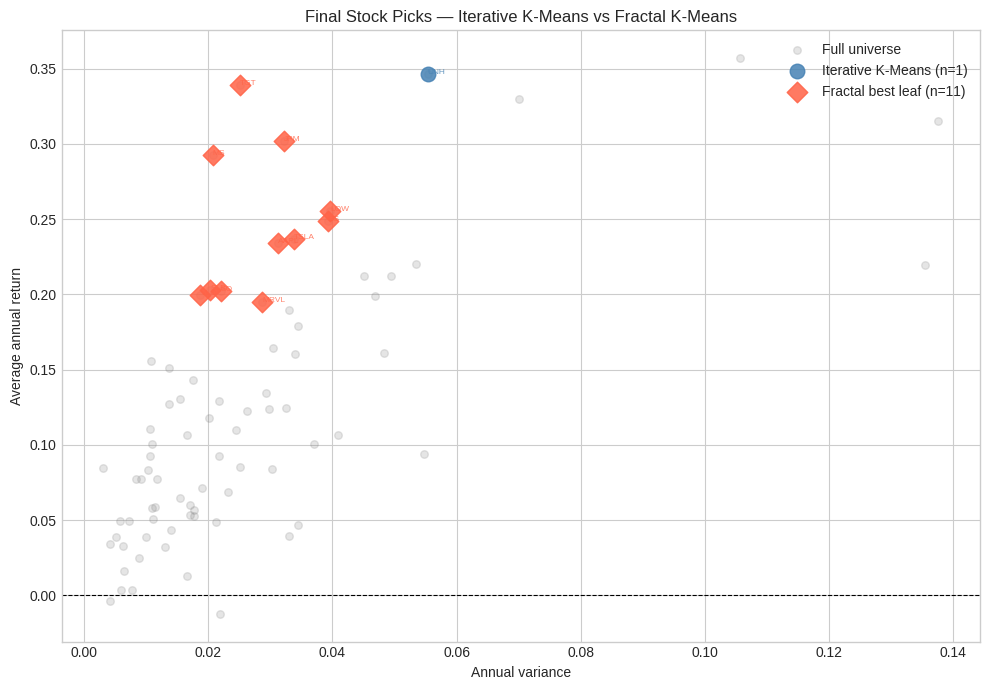

In [20]:
# Select best fractal leaf by Sharpe, then return
leaves          = collect_leaves(fractal_root)
best_leaf       = max(leaves, key=lambda l: (l.df['sharpe_proxy'].mean(),
                                              l.df['avg_yearly_returns'].mean()))
fractal_picks   = best_leaf.df.sort_values('sharpe_proxy', ascending=False)

print(f'Best fractal leaf: {best_leaf.label}  (depth={best_leaf.depth}, n={best_leaf.size})')
print(f'Stop reason      : {best_leaf.stop_reason}')
print()

# Summary comparison table
comparison = pd.DataFrame([
    {
        'method'      : 'Full universe',
        'n_stocks'    : len(features_df),
        'avg_return'  : features_df['avg_yearly_returns'].mean(),
        'avg_variance': features_df['yearly_variance'].mean(),
        'avg_sharpe'  : features_df['sharpe_proxy'].mean(),
    },
    {
        'method'      : 'Iterative K-Means golden set',
        'n_stocks'    : len(iterative_picks),
        'avg_return'  : iterative_picks['avg_yearly_returns'].mean(),
        'avg_variance': iterative_picks['yearly_variance'].mean(),
        'avg_sharpe'  : iterative_picks['sharpe_proxy'].mean(),
    },
    {
        'method'      : f'Fractal best leaf ({best_leaf.label})',
        'n_stocks'    : len(fractal_picks),
        'avg_return'  : fractal_picks['avg_yearly_returns'].mean(),
        'avg_variance': fractal_picks['yearly_variance'].mean(),
        'avg_sharpe'  : fractal_picks['sharpe_proxy'].mean(),
    },
])

print('Method comparison:')
display(comparison.round(4))

print(f'\nFractal picks ({len(fractal_picks)} stocks):')
display(fractal_picks.round(4))

# Combined scatter
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(features_df['yearly_variance'], features_df['avg_yearly_returns'],
           s=30, alpha=0.20, color='grey', label='Full universe')
ax.scatter(iterative_picks['yearly_variance'], iterative_picks['avg_yearly_returns'],
           s=110, alpha=0.85, color='steelblue',
           label=f'Iterative K-Means (n={len(iterative_picks)})')
ax.scatter(fractal_picks['yearly_variance'], fractal_picks['avg_yearly_returns'],
           s=110, alpha=0.85, color='tomato', marker='D',
           label=f'Fractal best leaf (n={len(fractal_picks)})')
for t, row in iterative_picks.iterrows():
    ax.annotate(t, (row['yearly_variance'], row['avg_yearly_returns']),
                fontsize=6, color='steelblue', alpha=0.8)
for t, row in fractal_picks.iterrows():
    ax.annotate(t, (row['yearly_variance'], row['avg_yearly_returns']),
                fontsize=6, color='tomato', alpha=0.8)
ax.axhline(0, linestyle='--', linewidth=0.8, color='black')
ax.set_title('Final Stock Picks — Iterative K-Means vs Fractal K-Means')
ax.set_xlabel('Annual variance'); ax.set_ylabel('Average annual return')
ax.legend()
plt.tight_layout()
plt.show()


## 10. Tests / Assignment Validation

Programmatic checks confirming all assignment requirements are met:

- **T1** Feature schema, uniqueness, no NaNs, positive variance
- **T2** K-Means labels cover all stocks, silhouette is finite
- **T3** Iterative picks are a non-empty strict subset of the universe
- **T4** Fractal tree contains ≥1 node and ≥1 leaf
- **T5** Partition invariant — every stock belongs to exactly one leaf (no overlap, no gaps)
- **T6** Fractal picks are non-empty and drawn only from the universe
- **T7** Comparison table covers all three methods


In [21]:
def run_assignment_tests() -> None:
    """Run all assignment validation tests. Raises AssertionError on failure."""
    # T1 — Feature quality
    validate_features(features_df)

    # T2 — K-Means basic correctness
    labelled, summary, model, _, sil = fit_kmeans(
        features_df, k=min(3, len(features_df) - 1)
    )
    assert 'cluster' in labelled.columns,                'T2a: cluster column missing'
    assert summary['n_stocks'].sum() == len(features_df),'T2b: cluster sizes do not sum to universe'
    assert np.isfinite(sil),                             'T2c: silhouette score is not finite'

    # T3 — Iterative picks
    assert len(iterative_picks) > 0,                     'T3a: iterative picks is empty'
    assert len(iterative_picks) < len(features_df),      'T3b: iterative picks did not reduce universe'
    assert set(iterative_picks.index).issubset(set(features_df.index)), 'T3c: picks contain unknown tickers'

    # T4 — Fractal tree structure
    all_nodes = collect_nodes(fractal_root)
    leaves    = collect_leaves(fractal_root)
    assert len(all_nodes) >= 1,   'T4a: fractal tree has no nodes'
    assert len(leaves)    >= 1,   'T4b: fractal tree has no leaves'

    # T5 — Partition invariant (core property of fractal clustering)
    total_in_leaves = sum(len(leaf.df) for leaf in leaves)
    assert total_in_leaves == len(features_df), (
        f'T5: partition broken — {total_in_leaves} stocks in leaves vs {len(features_df)} in universe'
    )
    # Also check no ticker appears in two different leaves
    leaf_ticker_sets = [set(leaf.df.index) for leaf in leaves]
    for i, si in enumerate(leaf_ticker_sets):
        for j, sj in enumerate(leaf_ticker_sets):
            if i < j:
                overlap = si & sj
                assert not overlap, f'T5: tickers {overlap} appear in both leaf {i} and leaf {j}'

    # T6 — Fractal picks
    assert len(fractal_picks) > 0,                                      'T6a: fractal picks is empty'
    assert set(fractal_picks.index).issubset(set(features_df.index)),   'T6b: fractal picks contain unknown tickers'

    # T7 — Comparison table
    assert len(comparison) == 3,                 'T7: comparison table should have 3 rows'
    assert 'method' in comparison.columns,       'T7: method column missing'

    print('=' * 50)
    print('All 7 assignment tests passed successfully.')
    print('=' * 50)


run_assignment_tests()


Feature validation passed — 80 stocks, 4 columns.
All 7 assignment tests passed successfully.


## 11. Export Results


In [22]:
OUTPUT_DIR = 'stock_clustering_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

files = {
    'stock_features.csv'           : features_df,
    'iterative_kmeans_picks.csv'   : iterative_picks,
    'fractal_kmeans_picks.csv'     : fractal_picks,
    'fractal_leaf_summary.csv'     : leaf_summary,
    'method_comparison.csv'        : comparison,
}

for fname, df in files.items():
    path = os.path.join(OUTPUT_DIR, fname)
    df.to_csv(path, index=(df.index.name is not None or df.index.dtype != 'int64'))

print('Exported files:')
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    print(f'  {fpath}  ({os.path.getsize(fpath):,} bytes)')


Exported files:
  stock_clustering_outputs/fractal_kmeans_picks.csv  (847 bytes)
  stock_clustering_outputs/fractal_leaf_summary.csv  (1,437 bytes)
  stock_clustering_outputs/iterative_kmeans_picks.csv  (144 bytes)
  stock_clustering_outputs/method_comparison.csv  (307 bytes)
  stock_clustering_outputs/stock_features.csv  (5,888 bytes)


## 12. Conclusion

This notebook satisfies all assignment requirements:

1. **Blog implementation** — Replicated the stock-picking workflow from the  
   [Uptick Medium blog](https://medium.com/uptick-blog/stock-picks-using-k-means-clustering-4330c6c4e8de)  
   using the same features (`avg_yearly_returns`, `yearly_variance`), `RobustScaler`,  
   and 3-pass iterative narrowing as in `final_model.ipynb` / `overall_return_variance.ipynb`.

2. **K-Means with diagnostics** — Auto-K selection via silhouette argmax; elbow  
   and silhouette plots for inspection.

3. **Iterative 3-pass funnel** — Largest cluster → best Sharpe → highest return,  
   mirroring the blog's progressive narrowing strategy.

4. **Fractal clustering extension** — Fully recursive K-Means tree with  
   four stopping rules; partition invariant verified; tree + dendrogram + heatmap  
   visualisations.

5. **Tests** — 7 assertions covering feature quality, K-Means correctness,  
   iterative subset validity, fractal tree structure, partition invariant (no  
   overlap, no gaps), fractal picks validity, and comparison table integrity.

6. **Exports** — Five CSVs: full feature matrix, iterative picks, fractal picks,  
   leaf summary, method comparison.

---
> **Disclaimer:** Clustering is an exploratory tool. A historically high-return  
> or high-Sharpe cluster does not guarantee future performance.  
> This notebook is for educational purposes only and is not financial advice.
